# Research Question
**To what extent do convolutional neural networks trained on 10 Sentinel-2 spectral bands classify land use and land cover more accurately than those trained on RGB bands alone, according to macro F1-score?**


In [21]:
# Import libraries
import json
import pandas as pd
import tifffile
import numpy as np
from scipy import stats
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

In [24]:
hits = list(Path('.').rglob(f'{CLASSES[0]}/*.tif*'))
print(len(hits))
print(hits[:3])

3000
[WindowsPath('MS/MS/AnnualCrop/AnnualCrop_1.tif'), WindowsPath('MS/MS/AnnualCrop/AnnualCrop_10.tif'), WindowsPath('MS/MS/AnnualCrop/AnnualCrop_100.tif')]


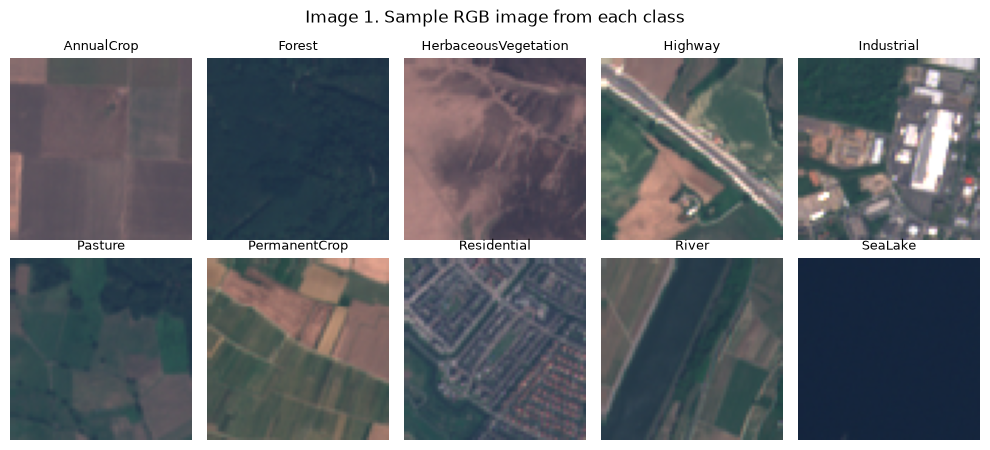

In [29]:
# Image 1. Sample RGB image from each class

DATA_DIR = Path('MS/MS')
SCALE = 3000  # reflectance x 10000; ~3000 maps typical land to full brightness

fig, axes = plt.subplots(2, 5, figsize=(10, 4.6))

for ax, cls in zip(axes.flat, CLASSES):
    path = sorted((DATA_DIR / cls).glob('*.tif'))[0]
    img = tifffile.imread(path).astype('float32')
    rgb = np.clip(img[:, :, BAND_IDX['rgb']] / SCALE, 0, 1)

    ax.imshow(rgb)
    ax.set_title(cls, fontsize=9)
    ax.axis('off')

fig.suptitle('Image 1. Sample RGB image from each class')
plt.tight_layout()
plt.savefig('image1_class_samples.png', dpi=300, bbox_inches='tight')
plt.show()

Read in results from train.py

In [2]:
RESULTS = Path('results/results')

rows = [json.loads(p.read_text()) for p in RESULTS.glob('*/metrics.json')]
df = pd.DataFrame(rows)

preds = {}
for run in df['run']:
    d = RESULTS / run
    preds[run] = {
        'y_prob': np.load(d / 'y_prob.npy'),
        'y_true': np.load(d / 'y_true.npy'),
        'test_ids': np.load(d / 'test_ids.npy'),
    }

# Every run was evaluated on the identical test set
ref = preds[df['run'][0]]['test_ids']
print(all(np.array_equal(p['test_ids'], ref) for p in preds.values()))

histories = {run: json.loads((RESULTS / run / 'history.json').read_text())
             for run in df['run']}

CLASSES = json.loads(Path('cache/classes.json').read_text())

True


Create seed pairs and calculate differences of F1-scores (MS - RGB)

In [3]:
paired = df.pivot(index='seed', columns='bands', values='test_macro_f1')
paired['diff'] = paired['ms'] - paired['rgb']
d = paired['diff']
n = len(d)

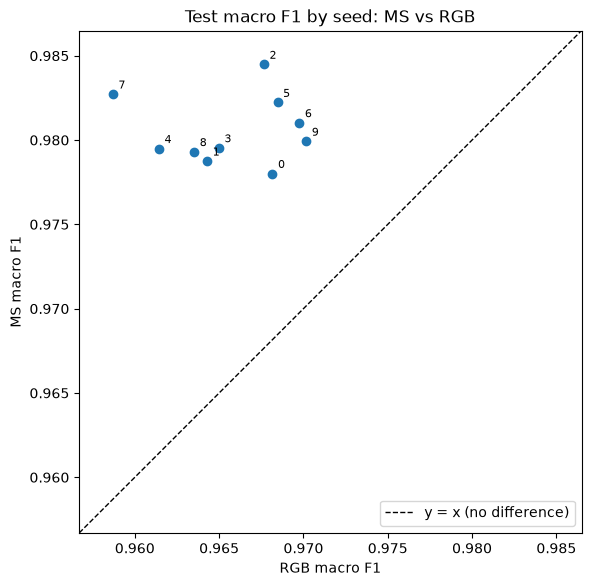

In [4]:
# Check for F1-score performance (MS vs RGB)

paired = df.pivot(index='seed', columns='bands', values='test_macro_f1')

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(paired['rgb'], paired['ms'])

for seed, row in paired.iterrows():
    ax.annotate(seed, (row['rgb'], row['ms']), xytext=(4, 4), textcoords='offset points', fontsize=8)

lo = paired.min().min() - 0.002
hi = paired.max().max() + 0.002
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label='y = x (no difference)')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal')

ax.set_xlabel('RGB macro F1')
ax.set_ylabel('MS macro F1')
ax.set_title('Test macro F1 by seed: MS vs RGB')
ax.legend()
plt.tight_layout()
plt.show()

# Figures

In [5]:
# Table 1

y = np.load('cache/y.npy')
train_idx = np.load('cache/train_idx.npy')
val_idx = np.load('cache/val_idx.npy')
test_idx = np.load('cache/test_idx.npy')

table1 = pd.DataFrame({
    'Class': CLASSES,
    'Images': np.bincount(y, minlength=10),
    'Train': np.bincount(y[train_idx], minlength=10),
    'Validation': np.bincount(y[val_idx], minlength=10),
    'Test': np.bincount(y[test_idx], minlength=10)
})
table1.loc[len(table1)] = ['Total', *table1.iloc[:, 1:].sum()]
table1

,Class,Images,Train,Validation,Test
0,AnnualCrop,3000,2100,450,450
1,Forest,3000,2100,450,450
2,HerbaceousVegetation,3000,2100,450,450
3,Highway,2500,1750,375,375
4,Industrial,2500,1750,375,375
5,Pasture,2000,1400,300,300
6,PermanentCrop,2500,1750,375,375
7,Residential,3000,2100,450,450
8,River,2500,1750,375,375
9,SeaLake,3000,2100,450,450


In [6]:
# Table 2

bands = pd.DataFrame({
    'TIFF index': range(13),
    'Band': ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07',
             'B08', 'B09', 'B10', 'B11', 'B12', 'B8A'],
    'Description': ['Coastal aerosol', 'Blue', 'Green', 'Red',
                    'Vegetation red edge 1', 'Vegetation red edge 2', 'Vegetation red edge 3',
                    'NIR', 'Water vapour', 'SWIR cirrus', 'SWIR 1', 'SWIR 2', 'Narrow NIR'],
    'Wavelength (nm)': [443, 493, 560, 665, 704, 740, 783, 833, 945, 1374, 1610, 2190, 865],
    'Resolution (m)': [60, 10, 10, 10, 20, 20, 20, 10, 60, 60, 20, 20, 20],
})

BAND_IDX = {'rgb': [3, 2, 1], 'ms': [1, 2, 3, 4, 5, 6, 7, 10, 11, 12]}
bands['RGB model'] = np.where(bands['TIFF index'].isin(BAND_IDX['rgb']), '✓', '')
bands['MS model'] = np.where(bands['TIFF index'].isin(BAND_IDX['ms']), '✓', '')

table2 = bands.sort_values('Wavelength (nm)').reset_index(drop=True)
table2

,TIFF index,Band,Description,Wavelength (nm),Resolution (m),RGB model,MS model
0,0,B01,Coastal aerosol,443,60,,
1,1,B02,Blue,493,10,✓,✓
2,2,B03,Green,560,10,✓,✓
3,3,B04,Red,665,10,✓,✓
4,4,B05,Vegetation red edge 1,704,20,,✓
5,5,B06,Vegetation red edge 2,740,20,,✓
6,6,B07,Vegetation red edge 3,783,20,,✓
7,7,B08,NIR,833,10,,✓
8,12,B8A,Narrow NIR,865,20,,✓
9,8,B09,Water vapour,945,60,,


In [7]:
# Table 3

prec, rec = [], []
for run in df['run']:
    y_true = np.load(RESULTS / run / 'y_true.npy')
    y_pred = np.load(RESULTS / run / 'y_prob.npy').argmax(axis=1)
    prec.append(precision_score(y_true, y_pred, average='macro'))
    rec.append(recall_score(y_true, y_pred, average='macro'))
df['test_prec'] = prec
df['test_rec'] = rec

metrics = {
    'Macro F1-score': ('test_macro_f1', 4),
    'Accuracy': ('test_acc', 4),
    'Macro precision': ('test_prec', 4),
    'Macro recall': ('test_rec', 4),
    'Epochs run': ('epochs_run', 1),
    'Best epoch': ('best_epoch', 1),
    'Training time per run (s)': ('train_seconds', 0),
}

table3 = []
for label, (col, dp) in metrics.items():
    row = {'Metric': label}
    for bands, name in [('rgb', 'RGB (mean +- SD)'), ('ms', 'MS (mean +- SD)')]:
        s = df.loc[df['bands'] == bands, col]
        row[name] = f'{s.mean():.{dp}f} +- {s.std():.{dp}f}'
    table3.append(row)
table3.append({'Metric': 'Parameters',
               'RGB (mean +- SD)': f"{df.loc[df['bands'] == 'rgb', 'params'].iloc[0]:,}",
               'MS (mean +- SD)': f"{df.loc[df['bands'] == 'ms', 'params'].iloc[0]:,}"})
table3 = pd.DataFrame(table3)
table3

,Metric,RGB (mean +- SD),MS (mean +- SD)
0,Macro F1-score,0.9657 +- 0.0038,0.9805 +- 0.0020
1,Accuracy,0.9665 +- 0.0037,0.9810 +- 0.0021
2,Macro precision,0.9659 +- 0.0037,0.9807 +- 0.0021
3,Macro recall,0.9657 +- 0.0038,0.9804 +- 0.0020
4,Epochs run,72.3 +- 6.5,57.8 +- 8.8
5,Best epoch,63.0 +- 7.6,47.8 +- 8.8
6,Training time per run (s),844 +- 76,944 +- 143
7,Parameters,"73,402","74,410"


In [8]:
# Table 4

table4 = df.pivot(index='seed', columns='bands', values='test_macro_f1')
table4['diff'] = table4['ms'] - table4['rgb']
table4.loc['Mean'] = table4.mean()
table4 = table4[['rgb', 'ms', 'diff']].round(4).reset_index()
table4.columns = ['Seed', 'RGB macro F1', 'MS macro F1', 'Difference (MS − RGB)']
table4

,Seed,RGB macro F1,MS macro F1,Difference (MS − RGB)
0,0,0.9682,0.9780,0.0099
1,1,0.9643,0.9787,0.0145
2,2,0.9677,0.9845,0.0168
3,3,0.9650,0.9795,0.0146
4,4,0.9614,0.9795,0.0181
5,5,0.9685,0.9822,0.0138
6,6,0.9698,0.9810,0.0113
7,7,0.9587,0.9827,0.0240
8,8,0.9635,0.9793,0.0158
9,9,0.9702,0.9799,0.0098


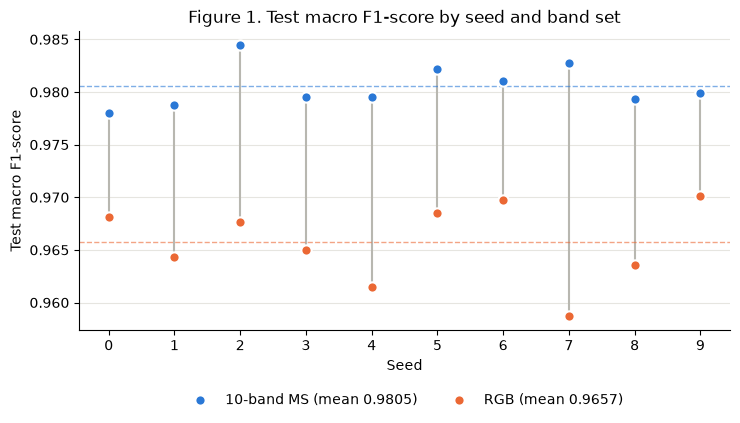

In [9]:
# Figure 1. Test macro F1-score by seed and band set

MS_COLOR = '#2a78d6'
RGB_COLOR = '#eb6834'

paired = df.pivot(index='seed', columns='bands', values='test_macro_f1')

fig, ax = plt.subplots(figsize=(7.5, 4.4))

# connector line for each seed's pair
ax.vlines(paired.index, paired['rgb'], paired['ms'], color='#b8b7b0', linewidth=1.5, zorder=1)

ax.scatter(paired.index, paired['ms'], s=55, color=MS_COLOR, edgecolor='white', linewidth=1.5,
           zorder=3, label=f"10-band MS (mean {paired['ms'].mean():.4f})")
ax.scatter(paired.index, paired['rgb'], s=55, color=RGB_COLOR, edgecolor='white', linewidth=1.5,
           zorder=3, label=f"RGB (mean {paired['rgb'].mean():.4f})")

# dashed line at each configuration's mean
ax.axhline(paired['ms'].mean(), color=MS_COLOR, linewidth=1, linestyle='--', alpha=0.6)
ax.axhline(paired['rgb'].mean(), color=RGB_COLOR, linewidth=1, linestyle='--', alpha=0.6)

ax.set_xticks(paired.index)
ax.set_title('Figure 1. Test macro F1-score by seed and band set')
ax.set_xlabel('Seed')
ax.set_ylabel('Test macro F1-score')
ax.grid(axis='y', color='#e6e5e0', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.17), ncol=2)

plt.tight_layout()
plt.savefig('fig1_f1_by_seed.png', dpi=300, bbox_inches='tight')
plt.show()

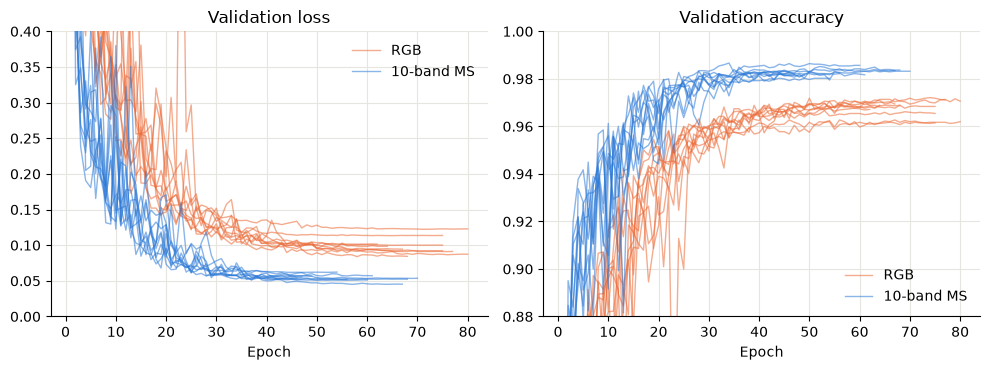

In [10]:
# Figure 2. Training history for MS and RGB

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

for bands, color, label in [('rgb', RGB_COLOR, 'RGB'), ('ms', MS_COLOR, '10-band MS')]:
    for seed in range(10):
        hist = json.loads((RESULTS / f'{bands}_seed{seed}' / 'history.json').read_text())
        epochs = range(1, len(hist['val_loss']) + 1)
        lab = label if seed == 0 else None
        axes[0].plot(epochs, hist['val_loss'], color=color, linewidth=1, alpha=0.55, label=lab)
        axes[1].plot(epochs, hist['val_accuracy'], color=color, linewidth=1, alpha=0.55, label=lab)

axes[0].set_ylim(0, 0.4)
axes[1].set_ylim(0.88, 1.0)
axes[0].set_title('Validation loss')
axes[1].set_title('Validation accuracy')

for ax in axes:
    ax.set_xlabel('Epoch')
    ax.grid(color='#e6e5e0', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('fig2_history.png', dpi=300, bbox_inches='tight')
plt.show()

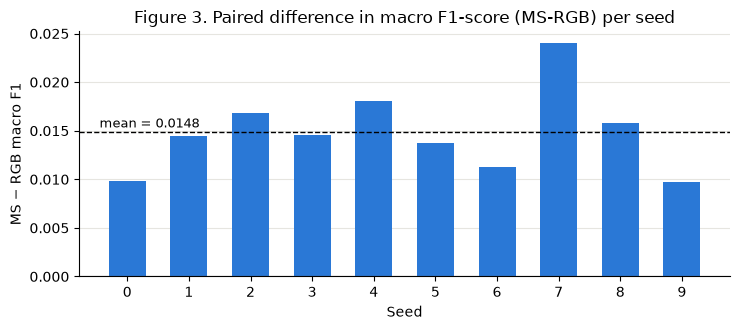

In [11]:
# Figure 3. Paired difference in macro F1-score (MS-RGB) per seed

paired = df.pivot(index='seed', columns='bands', values='test_macro_f1')
d = paired['ms'] - paired['rgb']

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.bar(d.index, d.values, color=MS_COLOR, width=0.6)
ax.axhline(d.mean(), color='black', linewidth=1, linestyle='--')
ax.text(-0.45, d.mean() + 0.0005, f'mean = {d.mean():.4f}', ha='left', fontsize=9)
ax.axhline(0, color='#8a8984', linewidth=0.8)

ax.set_xticks(d.index)
ax.set_xlabel('Seed')
ax.set_ylabel('MS − RGB macro F1')
ax.grid(axis='y', color='#e6e5e0', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Figure 3. Paired difference in macro F1-score (MS-RGB) per seed')

plt.tight_layout()
plt.savefig('fig3_paired_diff.png', dpi=300, bbox_inches='tight')
plt.show()


# Techniques







In [12]:
# Paired t-test

t = stats.ttest_rel(paired['ms'], paired['rgb'], alternative='greater')
print(f'Paired t-test:'
      f'\nt{n - 1} = {t.statistic:.4f}'
      f'\np-value: {t.pvalue:.7f}')
print(f'The sample mean distance is {t.statistic:.2f} standard errors away from 0.')

Paired t-test:
t9 = 10.9732
p-value: 0.0000008
The sample mean distance is 10.97 standard errors away from 0.


In [13]:
# Shapiro-Wilks test

shap = stats.shapiro(d)
print(f'Shapiro-Wilk on differences:'
      f'\nW = {shap.statistic:.4f}'
      f'\np-value = {shap.pvalue:.4f}')
if shap.pvalue > 0.05:
    print('No evidence against normality.')
else: print('The differences are not normally distributed.')

Shapiro-Wilk on differences:
W = 0.9245
p-value = 0.3956
No evidence against normality.


In [14]:
# Cohen's Dz test

se = d.std(ddof=1) / np.sqrt(n)
tc = stats.t.ppf(0.975, n-1)
print(f'95% confidence interval of mean difference: '
      f'{d.mean() - tc * se:.4f}, {d.mean() + tc * se:.4f}')
print(f"Cohen's dz: {d.mean() / d.std(ddof=1):.2f}")

95% confidence interval of mean difference: 0.0118, 0.0179
Cohen's dz: 3.47


In [15]:
# Wilcoxon signed-rank test

w = stats.wilcoxon(paired['ms'], paired['rgb'], alternative='greater')
print(f'Wilcoxon signed-rank (one-sided): W = {w.statistic:.0f}'
      f'\np_value = {w.pvalue:.4f}')

Wilcoxon signed-rank (one-sided): W = 55
p_value = 0.0010


In [16]:
# Screenshot 12. Code and output for per-class F1-score averages over seeds

rows = []
for run in df['run']:
    y_true = np.load(RESULTS / run / 'y_true.npy')
    y_prob = np.load(RESULTS / run / 'y_prob.npy')
    y_pred = y_prob.argmax(axis=1)
    for c, f in zip(CLASSES, f1_score(y_true, y_pred, average=None)):
        rows.append({'bands': run.split('_')[0],
                     'seed': int(run.split('seed')[1]),
                     'cls': c,
                     'f1': f})
pc = pd.DataFrame(rows)

per_class = pc.pivot_table(index='cls', columns='bands', values='f1', aggfunc='mean')
per_class['diff'] = per_class['ms'] - per_class['rgb']
print(per_class.sort_values('diff', ascending=False).round(4))

bands                     ms     rgb    diff
cls                                         
River                 0.9856  0.9473  0.0383
PermanentCrop         0.9615  0.9318  0.0296
AnnualCrop            0.9645  0.9386  0.0259
HerbaceousVegetation  0.9772  0.9590  0.0182
Pasture               0.9773  0.9641  0.0132
Highway               0.9743  0.9669  0.0074
SeaLake               0.9978  0.9905  0.0072
Industrial            0.9822  0.9771  0.0051
Forest                0.9956  0.9930  0.0025
Residential           0.9896  0.9888  0.0008


In [17]:
# Screenshot 13. Code and results for Holm test

rows = []
for c in CLASSES:
    s = pc[pc['cls'] == c].pivot(index='seed', columns='bands', values='f1')
    t = stats.ttest_rel(s['ms'], s['rgb'])
    rows.append({'cls': c, 'rgb': s['rgb'].mean(), 'ms': s['ms'].mean(),
                 'diff': (s['ms'] - s['rgb']).mean(), 't': t.statistic, 'p': t.pvalue})
holm = pd.DataFrame(rows).sort_values('p').reset_index(drop=True)

# Holm step-down adjustment
m = len(holm)
holm['p_holm'] = (holm['p'] * (m - holm.index)).cummax().clip(upper=1)
holm['significant'] = holm['p_holm'] < 0.05

out = holm.sort_values('diff', ascending=False).copy()
out[['rgb', 'ms', 'diff']] = out[['rgb', 'ms', 'diff']].round(4)
out['t'] = out['t'].round(2)
out['p'] = out['p'].map('{:.2e}'.format)
out['p_holm'] = out['p_holm'].map('{:.2e}'.format)
print(out.to_string(index=False))
print(f"\nSignificant after Holm correction: {holm['significant'].sum()} of {m} classes")

                 cls    rgb     ms   diff     t        p   p_holm  significant
               River 0.9473 0.9856 0.0383 15.77 7.32e-08 7.32e-07         True
       PermanentCrop 0.9318 0.9615 0.0296  7.80 2.70e-05 1.60e-04         True
          AnnualCrop 0.9386 0.9645 0.0259 11.61 1.02e-06 9.19e-06         True
HerbaceousVegetation 0.9590 0.9772 0.0182  7.81 2.67e-05 1.60e-04         True
             Pasture 0.9641 0.9773 0.0132  8.41 1.48e-05 1.04e-04         True
             Highway 0.9669 0.9743 0.0074  1.81 1.04e-01 2.08e-01        False
             SeaLake 0.9905 0.9978 0.0072 11.18 1.40e-06 1.12e-05         True
          Industrial 0.9771 0.9822 0.0051  4.00 3.11e-03 1.24e-02         True
              Forest 0.9930 0.9956 0.0025  3.20 1.08e-02 3.24e-02         True
         Residential 0.9888 0.9896 0.0008  0.65 5.35e-01 5.35e-01        False

Significant after Holm correction: 8 of 10 classes


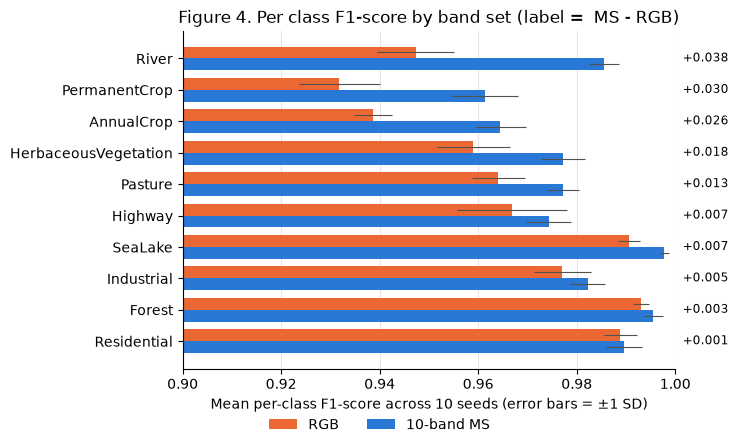

In [18]:
# Figure 4. Per class F1-score by band set (label =  MS - RGB)
class_stats = pc.groupby(['cls', 'bands'])['f1'].agg(['mean', 'std']).unstack('bands')
class_stats['diff'] = class_stats[('mean', 'ms')] - class_stats[('mean', 'rgb')]
class_stats = class_stats.sort_values('diff')

y = np.arange(len(class_stats))
h = 0.38

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.barh(y + h / 2, class_stats[('mean', 'rgb')], h, xerr=class_stats[('std', 'rgb')],
        color=RGB_COLOR, label='RGB', error_kw={'linewidth': 0.8, 'ecolor': '#52514e'})
ax.barh(y - h / 2, class_stats[('mean', 'ms')], h, xerr=class_stats[('std', 'ms')],
        color=MS_COLOR, label='10-band MS', error_kw={'linewidth': 0.8, 'ecolor': '#52514e'})

for i, diff in enumerate(class_stats['diff']):
    ax.text(1.0015, i, f'+{diff:.3f}', va='center', fontsize=8.5)

ax.set_yticks(y)
ax.set_yticklabels(class_stats.index)
ax.set_xlim(0.90, 1.0)
ax.set_xlabel('Mean per-class F1-score across 10 seeds (error bars = ±1 SD)')
ax.set_title('Figure 4. Per class F1-score by band set (label =  MS - RGB)')
ax.grid(axis='x', color='#e6e5e0', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.4, -0.11), ncol=2)

plt.tight_layout()
plt.savefig('fig4_per_class.png', dpi=300, bbox_inches='tight')
plt.show()

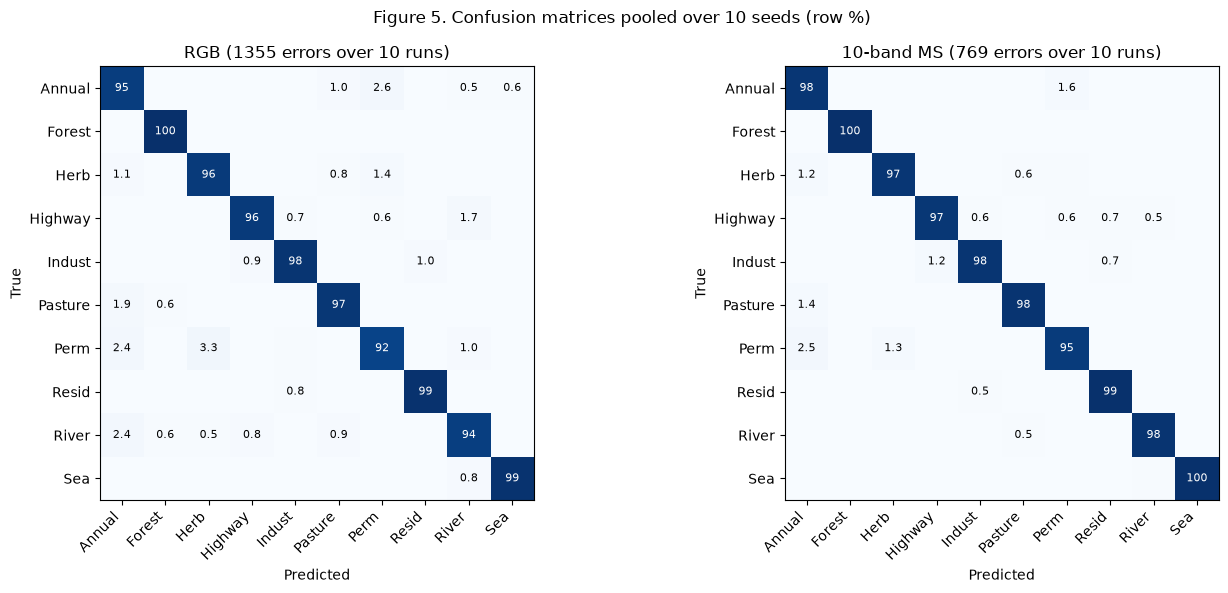

In [19]:
# Figure 5. Confusion matrices pooled over 10 seeds (row %)

short = ['Annual', 'Forest', 'Herb', 'Highway', 'Indust',
         'Pasture', 'Perm', 'Resid', 'River', 'Sea']

cms = {}
for bands in ['rgb', 'ms']:
    cm = np.zeros((10, 10), dtype=int)
    for seed in range(10):
        run = f'{bands}_seed{seed}'
        y_true = np.load(RESULTS / run / 'y_true.npy')
        y_pred = np.load(RESULTS / run / 'y_prob.npy').argmax(axis=1)
        cm += confusion_matrix(y_true, y_pred, labels=range(10))
    cms[bands] = cm

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, bands, title in zip(axes, ['rgb', 'ms'], ['RGB', '10-band MS']):
    cm = cms[bands]
    row_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    ax.imshow(row_pct, cmap='Blues', vmin=0, vmax=100)

    for i in range(10):
        for j in range(10):
            v = row_pct[i, j]
            if v >= 0.5:
                ax.text(j, i, f'{v:.1f}' if v < 10 else f'{v:.0f}',
                        ha='center', va='center', fontsize=8,
                        color='white' if v > 50 else 'black')

    errors = cm.sum() - np.trace(cm)
    ax.set_title(f'{title} ({errors} errors over 10 runs)')
    ax.set_xticks(range(10))
    ax.set_xticklabels(short, rotation=45, ha='right')
    ax.set_yticks(range(10))
    ax.set_yticklabels(short)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

fig.suptitle('Figure 5. Confusion matrices pooled over 10 seeds (row %)')
plt.tight_layout()
plt.show()